# **NeuroScan AI**

Proyecto Final de Sistemas Inteligentes



*   Melisa Ortiz Morante
*   Santiago Sepúlveda Landeros



1. Subir Credenciales y configurar Kaggle

In [ ]:
# Celda 1 — Configurar nuevo token de Kaggle en Colab
import os

KAGGLE_TOKEN = "KGAT_8b44bc94edaacb0e3e852ae508d56447"

# Guardarlo en la ruta que espera la CLI nueva
os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/access_token", "w") as f:
    f.write(KAGGLE_TOKEN)
os.chmod("/root/.kaggle/access_token", 0o600)

# Verificar que la CLI lo reconoce
result = os.popen("kaggle competitions list 2>&1 | head -3").read()
print(result)
print("✅ Kaggle configurado con nuevo token")

ref                                                                              deadline             category         reward  teamCount  userHasEntered  
-------------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge      2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  

✅ Kaggle configurado con nuevo token


2. Descarga del dataset

In [ ]:
# Descargar dataset (~150 MB) directamente desde Kaggle
os.system("kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset")

# Extraer y organizar
os.system("unzip -q brain-tumor-mri-dataset.zip -d brain_tumor_data")

# Verificar estructura de carpetas
for root, dirs, files in os.walk("brain_tumor_data"):
    level = root.count(os.sep)
    indent = " " * 3 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level == 2:
        print(f"{indent}   → {len(files)} imágenes")

brain_tumor_data/
   Testing/
      pituitary/
         → 400 imágenes
      meningioma/
         → 400 imágenes
      glioma/
         → 400 imágenes
      notumor/
         → 400 imágenes
   Training/
      pituitary/
         → 1400 imágenes
      meningioma/
         → 1400 imágenes
      glioma/
         → 1400 imágenes
      notumor/
         → 1400 imágenes


3. Analisis exploratoirio EDA

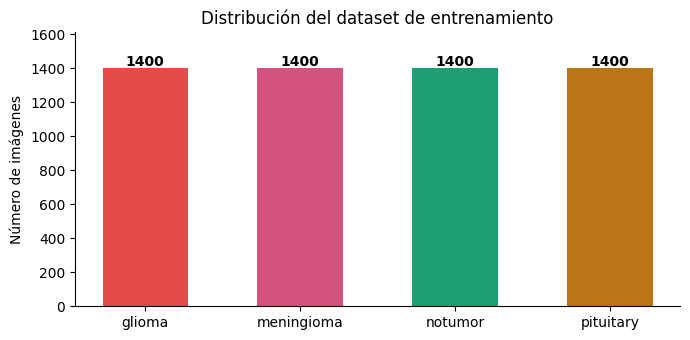


Total entrenamiento: 5,600 imágenes
Clase más pequeña: 1400 | más grande: 1400
Ratio max/min: 1.00x  → dataset completamente balanceado ✅


In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np

TRAIN_DIR = "brain_tumor_data/Training"
clases    = sorted(os.listdir(TRAIN_DIR))
conteos   = [len(os.listdir(f"{TRAIN_DIR}/{c}")) for c in clases]

fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.bar(clases, conteos,
              color=["#E24B4A", "#D4537E", "#1D9E75", "#BA7517"],
              edgecolor="none", width=0.55)

for bar, n in zip(bars, conteos):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            str(n), ha="center", fontsize=10, fontweight="bold")

ax.set_title("Distribución del dataset de entrenamiento", fontsize=12)
ax.set_ylabel("Número de imágenes")
ax.set_ylim(0, max(conteos) * 1.15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

print(f"\nTotal entrenamiento: {sum(conteos):,} imágenes")
print(f"Clase más pequeña: {min(conteos)} | más grande: {max(conteos)}")
print(f"Ratio max/min: {max(conteos)/min(conteos):.2f}x  → dataset completamente balanceado ✅")

4. Visualizar Muestras por clase

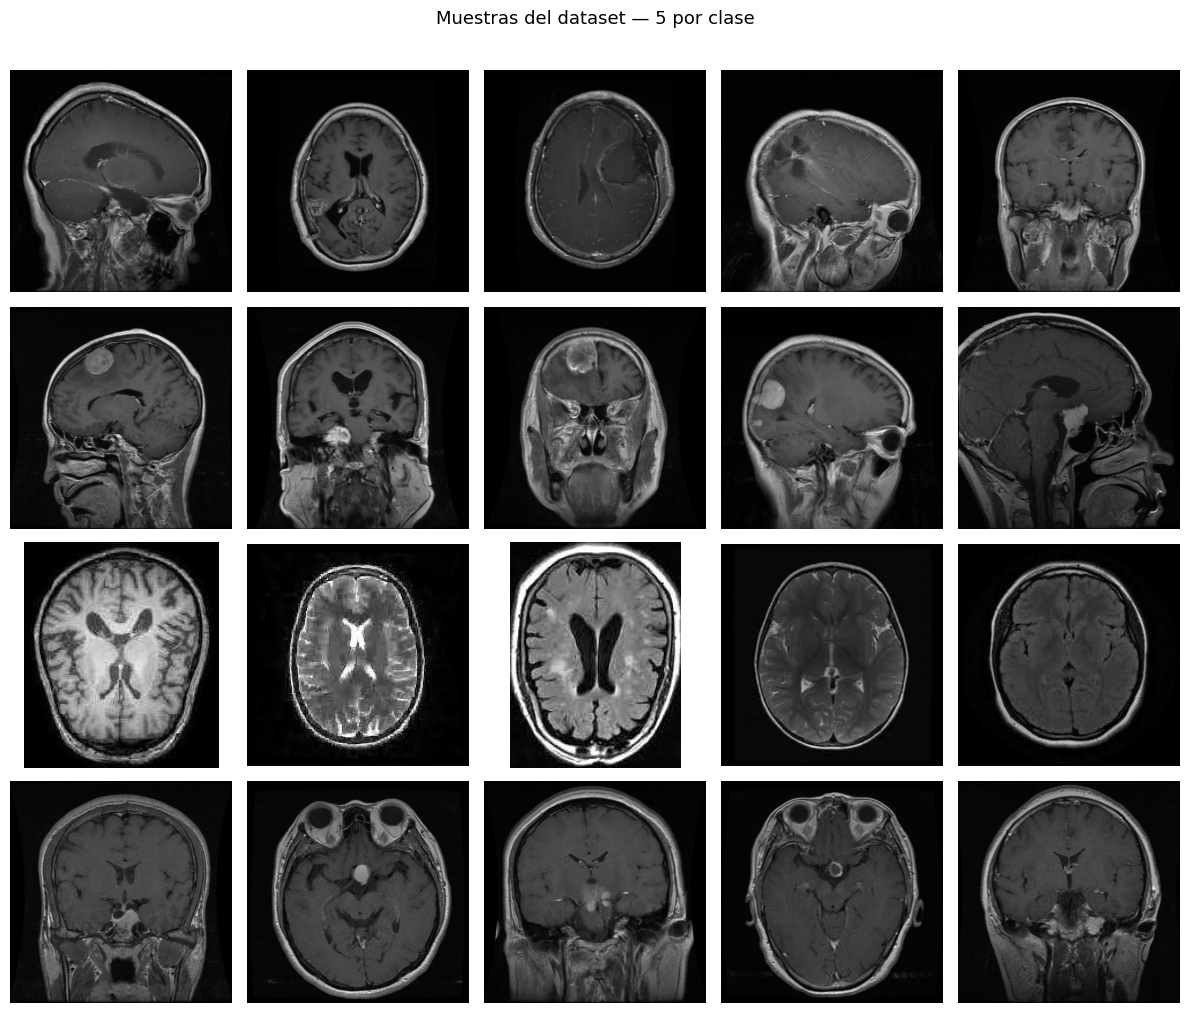

Tamaño de muestra: (512, 512) | Modo: L
→ Redimensionaremos todo a 224×224 para EfficientNetB0


In [ ]:
import random
from PIL import Image

LABELS = {"glioma": "Glioma", "meningioma": "Meningioma",
          "notumor": "Sin tumor", "pituitary": "Tumor pituitario"}

fig, axes = plt.subplots(4, 5, figsize=(12, 10))
fig.suptitle("Muestras del dataset — 5 por clase", fontsize=13, y=1.01)

for row, clase in enumerate(clases):
    carpeta = f"{TRAIN_DIR}/{clase}"
    imgs    = random.sample(os.listdir(carpeta), 5)
    for col, fname in enumerate(imgs):
        img = Image.open(f"{carpeta}/{fname}").convert("RGB")
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_ylabel(LABELS[clase], fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

# Verificar dimensiones típicas de las imágenes
sample_path = f"{TRAIN_DIR}/{clases[0]}/{os.listdir(f'{TRAIN_DIR}/{clases[0]}')[0]}"
img_sample  = Image.open(sample_path)
print(f"Tamaño de muestra: {img_sample.size} | Modo: {img_sample.mode}")
print("→ Redimensionaremos todo a 224×224 para EfficientNetB0")

5. Verificar estatus de GPU

In [ ]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo: {device}")

if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM disponible: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠️  Sin GPU. Ve a: Entorno de ejecución → Cambiar tipo → T4 GPU")

Dispositivo: cuda
GPU: Tesla T4
VRAM disponible: 15.6 GB


6. Importaciones para transformación

In [ ]:
import torch
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np

TRAIN_DIR = "brain_tumor_data/Training"
TEST_DIR  = "brain_tumor_data/Testing"
IMG_SIZE  = 224   # tamaño que espera EfficientNetB0
BATCH     = 32
VAL_SPLIT = 0.15  # 15% del train → validación
SEED      = 42
torch.manual_seed(SEED)

7. Transformación y normalización de datos

In [ ]:
# Estadísticas de ImageNet — usamos estas porque el modelo fue preentrenado con ellas
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ── Entrenamiento: con augmentation ──────────────────────────────────────────
train_transforms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.RandomGrayscale(p=0.1),
    T.ToTensor(),                                        # ← primero convertir a tensor
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    T.RandomErasing(p=0.1, scale=(0.02, 0.08)),          # ← ahora sí funciona
])

# ── Validación y test: sin augmentation, solo normalizar ─────────────────────
val_test_transforms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("✅ Transformaciones definidas")
print(f"   Train : {len(train_transforms.transforms)} pasos")
print(f"   Val/Test: {len(val_test_transforms.transforms)} pasos")

✅ Transformaciones definidas
   Train : 9 pasos
   Val/Test: 3 pasos


8. Crear datasets transformados

In [ ]:
# Cargar dataset completo de entrenamiento con transforms de train
full_train = ImageFolder(root=TRAIN_DIR, transform=train_transforms)

# Split train / validación (85% / 15%)
n_val   = int(len(full_train) * VAL_SPLIT)
n_train = len(full_train) - n_val
train_dataset, val_dataset = random_split(
    full_train, [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED)
)

# Aplicar transforms de val al subset de validación
# (random_split hereda el transform de full_train, lo sobreescribimos)
val_dataset.dataset = ImageFolder(root=TRAIN_DIR, transform=val_test_transforms)

# Dataset de test independiente
test_dataset = ImageFolder(root=TEST_DIR, transform=val_test_transforms)

# Mapeo de clases
CLASS_NAMES = full_train.classes
CLASS_TO_IDX = full_train.class_to_idx

print("Clases detectadas:", CLASS_NAMES)
print(f"\nTamaños:")
print(f"  Train : {n_train:,} imágenes")
print(f"  Val   : {n_val:,} imágenes")
print(f"  Test  : {len(test_dataset):,} imágenes")

Clases detectadas: ['glioma', 'meningioma', 'notumor', 'pituitary']

Tamaños:
  Train : 4,760 imágenes
  Val   : 840 imágenes
  Test  : 1,600 imágenes


9. Dataloaders

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH,
    shuffle=True,      # mezclar en cada época
    num_workers=2,     # carga en paralelo
    pin_memory=True,   # acelera transferencia CPU → GPU
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

# Verificar un batch
imgs, labels = next(iter(train_loader))
print(f"Shape de un batch → imágenes: {imgs.shape}")
print(f"                  → etiquetas: {labels.shape}")
print(f"Dtype: {imgs.dtype} | Rango aprox: [{imgs.min():.2f}, {imgs.max():.2f}]")

Shape de un batch → imágenes: torch.Size([32, 3, 224, 224])
                  → etiquetas: torch.Size([32])
Dtype: torch.float32 | Rango aprox: [-2.12, 2.64]


10. Ver efecto de augmentación

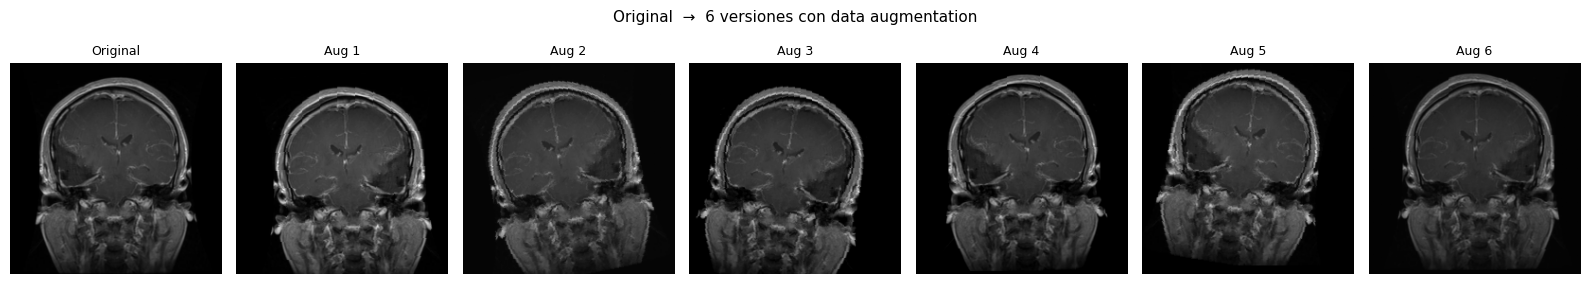

✅ Augmentation verificado — variaciones realistas, tumor siempre visible


In [ ]:
def denormalize(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    std  = torch.tensor(IMAGENET_STD).view(3,1,1)
    return (tensor * std + mean).clamp(0, 1)

# Cargar imagen como PIL directamente (sin ToTensor)
from PIL import Image
sample_path = full_train.samples[0][0]
img_pil = Image.open(sample_path).convert("RGB")

# Augmentaciones sin ToTensor ni Normalize (operan sobre PIL)
aug_only = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.RandomGrayscale(p=0.1),
    T.ToTensor(),   # ← solo para poder hacer imshow
])

fig, axes = plt.subplots(1, 7, figsize=(16, 3))
fig.suptitle("Original  →  6 versiones con data augmentation", fontsize=11)

img_tensor = T.Compose([T.Resize((IMG_SIZE, IMG_SIZE)), T.ToTensor()])(img_pil)
axes[0].imshow(img_tensor.permute(1,2,0))
axes[0].set_title("Original", fontsize=9)
axes[0].axis("off")

for i in range(1, 7):
    aug_img = aug_only(img_pil)
    axes[i].imshow(aug_img.permute(1,2,0).clamp(0,1))
    axes[i].set_title(f"Aug {i}", fontsize=9)
    axes[i].axis("off")

plt.tight_layout()
plt.show()
print("✅ Augmentation verificado — variaciones realistas, tumor siempre visible")

# 11. Cargar modelo Base

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

device = "cuda" if torch.cuda.is_available() else "cpu"
NUM_CLASSES = 4

# Cargar EfficientNetB0 con pesos preentrenados en ImageNet
model = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
)

print("Arquitectura original (última capa):")
print(model.classifier)
print(f"\nTotal parámetros: {sum(p.numel() for p in model.parameters()):,}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 223MB/s]

Arquitectura original (última capa):
Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)

Total parámetros: 5,288,548


# 12. Congelamiento de backbone y descongelamiento de cabeza

In [ ]:
# FASE 1: Congelar todo el backbone (features)
# Solo entrenaremos la nueva cabeza clasificadora al inicio
for param in model.features.parameters():
    param.requires_grad = False

# FASE 2: Reemplazar el clasificador original (1000 clases ImageNet)
# por uno nuevo de 4 clases (nuestro target)
model.classifier = nn.Sequential(
    nn.Dropout(p=0.4, inplace=True),          # más dropout que el original (regularización)
    nn.Linear(1280, 512),                      # capa intermedia nueva
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(512, NUM_CLASSES),               # salida: 4 clases
)

model = model.to(device)

# Contar parámetros entrenables vs congelados
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen    = sum(p.numel() for p in model.parameters() if not p.requires_grad)

print("Nueva cabeza clasificadora:")
print(model.classifier)
print(f"\nParámetros entrenables : {trainable:,}  ({100*trainable/(trainable+frozen):.1f}%)")
print(f"Parámetros congelados  : {frozen:,}  ({100*frozen/(trainable+frozen):.1f}%)")

Nueva cabeza clasificadora:
Sequential(
  (0): Dropout(p=0.4, inplace=True)
  (1): Linear(in_features=1280, out_features=512, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.3, inplace=False)
  (4): Linear(in_features=512, out_features=4, bias=True)
)

Parámetros entrenables : 657,924  (14.1%)
Parámetros congelados  : 4,007,548  (85.9%)


# 13. Loss, optimizador y scheduler

In [ ]:
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Solo pasamos los parámetros entrenables al optimizador
optimizer = Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,        # LR alto para la cabeza nueva
    weight_decay=1e-4
)

# Reduce LR cuando val_loss no mejora en 3 épocas
scheduler = ReduceLROnPlateau(
    optimizer, mode="min", factor=0.3, patience=3
)

# CrossEntropy estándar — dataset balanceado, no necesitamos pesos
criterion = nn.CrossEntropyLoss()

print("✅ Configuración lista para FASE 1 (solo cabeza)")
print(f"   Optimizador : Adam  lr=1e-3")
print(f"   Scheduler   : ReduceLROnPlateau  patience=3")
print(f"   Loss        : CrossEntropyLoss")

✅ Configuración lista para FASE 1 (solo cabeza)
   Optimizador : Adam  lr=1e-3
   Scheduler   : ReduceLROnPlateau  patience=3
   Loss        : CrossEntropyLoss


# 14. Descongelamiento progresivo

In [ ]:
def unfreeze_backbone(model, lr_backbone=1e-5):
    """
    Fase 2 del fine-tuning: descongelar todo el backbone
    con un LR muy pequeño para no destruir los pesos preentrenados.
    Se llama automáticamente durante el entrenamiento.
    """
    for param in model.features.parameters():
        param.requires_grad = True

    # LR diferenciado: backbone lento, cabeza más rápido
    optimizer_full = Adam([
        {"params": model.features.parameters(), "lr": lr_backbone},
        {"params": model.classifier.parameters(), "lr": lr_backbone * 10},
    ], weight_decay=1e-4)

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"🔓 Backbone descongelado — {trainable:,} parámetros entrenables")
    print(f"   backbone lr={lr_backbone:.0e} | cabeza lr={lr_backbone*10:.0e}")
    return optimizer_full

print("✅ Función unfreeze_backbone() lista")
print("   Se llamará la fase 4 durante el loop de entrenamiento")

✅ Función unfreeze_backbone() lista
   Se llamará la fase 4 durante el loop de entrenamiento


# 15. Clase EarlyStopping

In [ ]:
import numpy as np

class EarlyStopping:
    """
    Detiene el entrenamiento si val_loss no mejora en `patience` épocas.
    Guarda el mejor modelo automáticamente.
    """
    def __init__(self, patience=5, delta=1e-4, path="best_model.pt"):
        self.patience  = patience
        self.delta     = delta
        self.path      = path
        self.counter   = 0
        self.best_loss = None
        self.stop      = False

    def __call__(self, val_loss, model):
        if self.best_loss is None or val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.counter   = 0
            torch.save(model.state_dict(), self.path)
            print(f"   💾 Mejor modelo guardado (val_loss={val_loss:.4f})")
        else:
            self.counter += 1
            print(f"   ⚠️  Sin mejora {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.stop = True

early_stopping = EarlyStopping(patience=5, path="best_model.pt")
print("✅ EarlyStopping listo (patience=5)")

✅ EarlyStopping listo (patience=5)


# 16. train_epoch y val_epoch

In [ ]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        preds      = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    return total_loss / total, correct / total


def val_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs    = model(imgs)
            loss       = criterion(outputs, labels)
            total_loss += loss.item() * imgs.size(0)
            preds      = outputs.argmax(dim=1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)

    return total_loss / total, correct / total

print("✅ Funciones train_epoch y val_epoch listas")

✅ Funciones train_epoch y val_epoch listas


# 17. Loop principal

In [ ]:
EPOCHS_FASE1 = 10   # solo cabeza congelada
EPOCHS_FASE2 = 20   # backbone descongelado
EPOCHS_TOTAL = EPOCHS_FASE1 + EPOCHS_FASE2

history = {"train_loss": [], "val_loss": [],
           "train_acc":  [], "val_acc":  []}

print("=" * 60)
print("FASE 1 — Entrenando solo la cabeza clasificadora")
print("=" * 60)

for epoch in range(1, EPOCHS_TOTAL + 1):

    # ── Cambio de fase ─────────────────────────────────────────────
    if epoch == EPOCHS_FASE1 + 1:
        print("\n" + "=" * 60)
        print("FASE 2 — Fine-tuning completo (backbone descongelado)")
        print("=" * 60)
        optimizer = unfreeze_backbone(model, lr_backbone=1e-5)
        scheduler = ReduceLROnPlateau(optimizer, mode="min",
                                      factor=0.3, patience=3)
        early_stopping = EarlyStopping(patience=7, path="best_model.pt")

    # ── Entrenamiento y validación ──────────────────────────────────
    tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    vl_loss, vl_acc = val_epoch(model, val_loader, criterion, device)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)

    fase = "F1" if epoch <= EPOCHS_FASE1 else "F2"
    print(f"[{fase}] Época {epoch:02d}/{EPOCHS_TOTAL} | "
          f"train_loss={tr_loss:.4f} acc={tr_acc:.3f} | "
          f"val_loss={vl_loss:.4f} acc={vl_acc:.3f}")

    scheduler.step(vl_loss)
    early_stopping(vl_loss, model)
    if early_stopping.stop:
        print(f"\n🛑 Early stopping en época {epoch}")
        break

print("\n✅ Entrenamiento completo — mejor modelo en best_model.pt")

FASE 1 — Entrenando solo la cabeza clasificadora
[F1] Época 01/30 | train_loss=0.5729 acc=0.781 | val_loss=0.3898 acc=0.844
   💾 Mejor modelo guardado (val_loss=0.3898)
[F1] Época 02/30 | train_loss=0.4332 acc=0.838 | val_loss=0.3251 acc=0.879
   💾 Mejor modelo guardado (val_loss=0.3251)
[F1] Época 03/30 | train_loss=0.3956 acc=0.853 | val_loss=0.3209 acc=0.873
   💾 Mejor modelo guardado (val_loss=0.3209)
[F1] Época 04/30 | train_loss=0.3857 acc=0.856 | val_loss=0.3077 acc=0.883
   💾 Mejor modelo guardado (val_loss=0.3077)
[F1] Época 05/30 | train_loss=0.3588 acc=0.864 | val_loss=0.2810 acc=0.898
   💾 Mejor modelo guardado (val_loss=0.2810)
[F1] Época 06/30 | train_loss=0.3362 acc=0.871 | val_loss=0.2786 acc=0.900
   💾 Mejor modelo guardado (val_loss=0.2786)
[F1] Época 07/30 | train_loss=0.3412 acc=0.874 | val_loss=0.2772 acc=0.895
   💾 Mejor modelo guardado (val_loss=0.2772)
[F1] Época 08/30 | train_loss=0.3345 acc=0.872 | val_loss=0.2586 acc=0.900
   💾 Mejor modelo guardado (val_loss

# 18. Graficar curvas train vs val

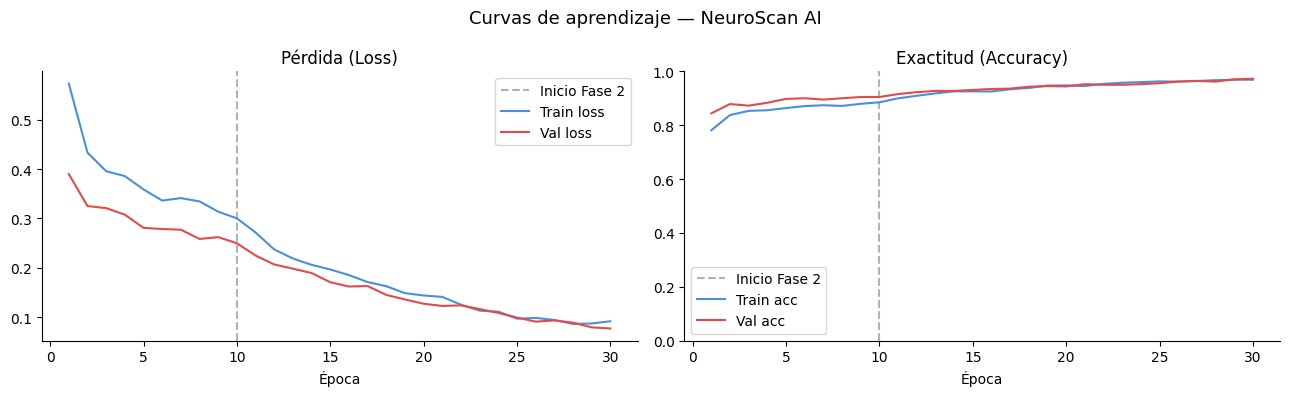

✅ Curvas guardadas en learning_curves.png


In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
epochs_ran = range(1, len(history["train_loss"]) + 1)

# Línea divisora entre fases
for ax in (ax1, ax2):
    ax.axvline(x=EPOCHS_FASE1, color="gray", linestyle="--",
               alpha=0.6, label="Inicio Fase 2")

# Loss
ax1.plot(epochs_ran, history["train_loss"], label="Train loss", color="#4A90D9")
ax1.plot(epochs_ran, history["val_loss"],   label="Val loss",   color="#E24B4A")
ax1.set_title("Pérdida (Loss)")
ax1.set_xlabel("Época")
ax1.legend()
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# Accuracy
ax2.plot(epochs_ran, history["train_acc"], label="Train acc", color="#4A90D9")
ax2.plot(epochs_ran, history["val_acc"],   label="Val acc",   color="#E24B4A")
ax2.set_title("Exactitud (Accuracy)")
ax2.set_xlabel("Época")
ax2.set_ylim(0, 1)
ax2.legend()
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.suptitle("Curvas de aprendizaje — NeuroScan AI", fontsize=13)
plt.tight_layout()
plt.savefig("learning_curves.png", dpi=150)
plt.show()
print("✅ Curvas guardadas en learning_curves.png")

# 19. Restaurar a mejor checkpoint

In [ ]:
# Cargar el mejor modelo guardado por EarlyStopping
model.load_state_dict(torch.load("best_model.pt", map_location=device))
model.eval()
print("✅ Mejor modelo restaurado y listo para evaluación")
print(f"   Mejor val_loss alcanzado: {early_stopping.best_loss:.4f}")

✅ Mejor modelo restaurado y listo para evaluación
   Mejor val_loss alcanzado: 0.0774


# 20. Acuracy, F1, reporte completo

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, f1_score
import torch

# Recolectar predicciones sobre el test set completo
all_preds, all_labels = [], []
model.eval()

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs   = imgs.to(device)
        outputs = model(imgs)
        preds   = outputs.argmax(dim=1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

# Métricas globales
acc    = accuracy_score(all_labels, all_preds)
f1_mac = f1_score(all_labels, all_preds, average="macro")
f1_wgt = f1_score(all_labels, all_preds, average="weighted")

print("=" * 50)
print(f"  Accuracy  (test): {acc:.4f}  ({acc*100:.2f}%)")
print(f"  F1 macro  (test): {f1_mac:.4f}")
print(f"  F1 weighted     : {f1_wgt:.4f}")
print("=" * 50)

# Reporte por clase
print("\nReporte por clase:")
print(classification_report(
    all_labels, all_preds,
    target_names=CLASS_NAMES
))

  Accuracy  (test): 0.9325  (93.25%)
  F1 macro  (test): 0.9301
  F1 weighted     : 0.9301

Reporte por clase:
              precision    recall  f1-score   support

      glioma       1.00      0.75      0.85       400
  meningioma       0.86      0.99      0.92       400
     notumor       0.92      1.00      0.96       400
   pituitary       0.99      0.99      0.99       400

    accuracy                           0.93      1600
   macro avg       0.94      0.93      0.93      1600
weighted avg       0.94      0.93      0.93      1600



# 21. Matriz de confusión

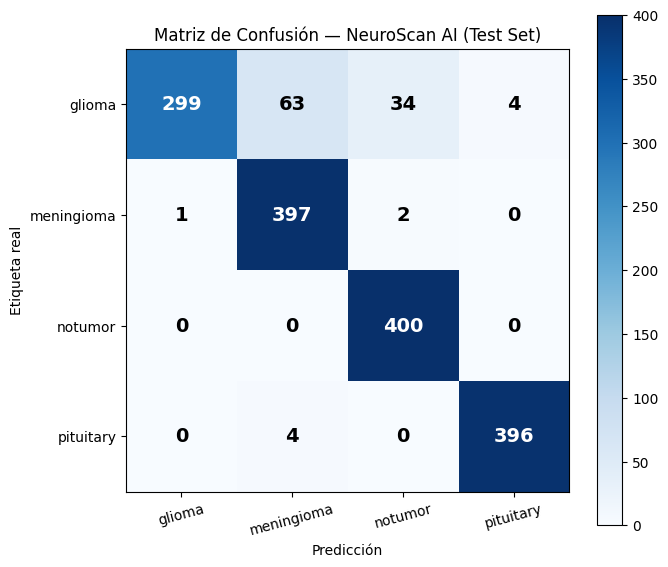

✅ Guardada en confusion_matrix.png


In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im, ax=ax)

ax.set_xticks(range(4))
ax.set_yticks(range(4))
ax.set_xticklabels(CLASS_NAMES, rotation=15)
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicción")
ax.set_ylabel("Etiqueta real")
ax.set_title("Matriz de Confusión — NeuroScan AI (Test Set)")

# Anotar cada celda con el número
for i in range(4):
    for j in range(4):
        color = "white" if cm[i,j] > cm.max() / 2 else "black"
        ax.text(j, i, str(cm[i,j]), ha="center", va="center",
               color=color, fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("✅ Guardada en confusion_matrix.png")

# 22. Instalar GRAD CAM

In [ ]:
!pip install -q grad-cam
print("✅ grad-cam instalado")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 121.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
✅ grad-cam instalado


# 23. Vusualizar GRAD CAM por clase

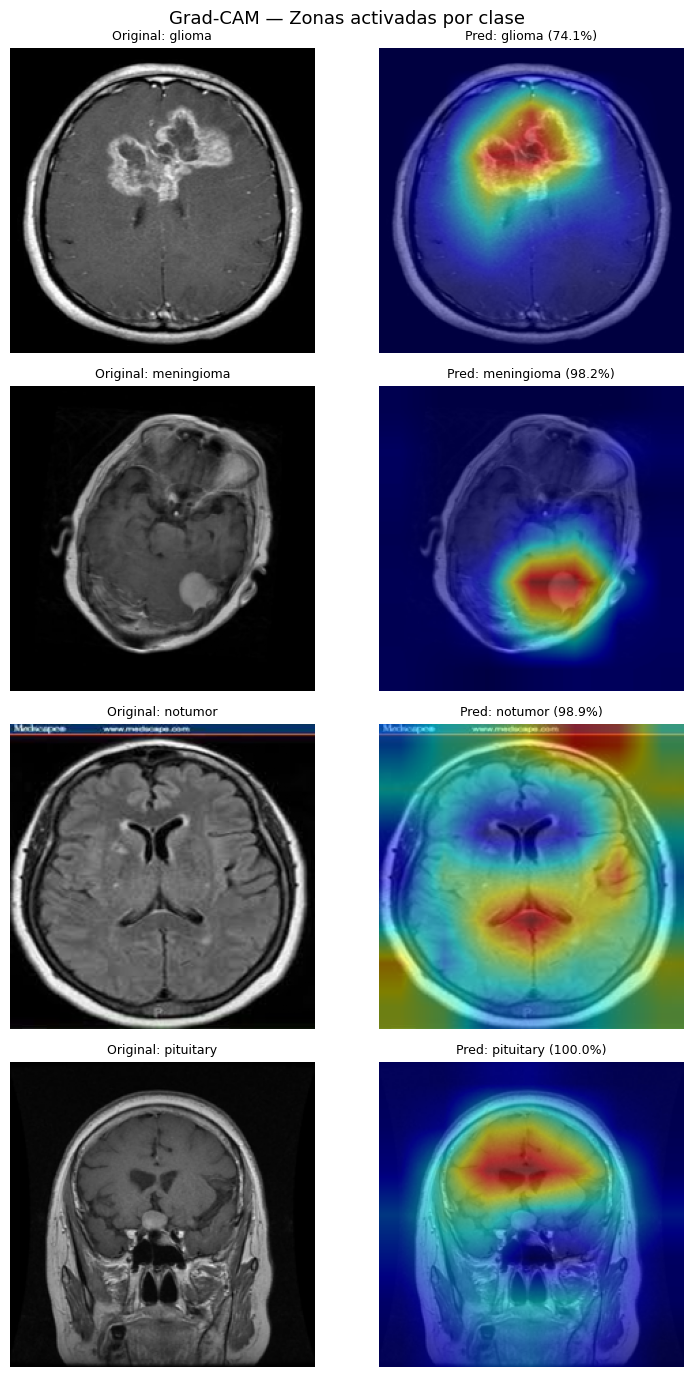

✅ Grad-CAM guardado en gradcam.png


In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from PIL import Image
import torchvision.transforms as T
import numpy as np
import matplotlib.pyplot as plt

# Última capa convolucional de EfficientNetB0
target_layer = [model.features[-1]]

fig, axes = plt.subplots(4, 2, figsize=(8, 14))
fig.suptitle("Grad-CAM — Zonas activadas por clase", fontsize=13)

with GradCAM(model=model, target_layers=target_layer) as cam:
    for idx, clase in enumerate(CLASS_NAMES):

        # Tomar una imagen del test set de esa clase
        clase_idx   = test_dataset.class_to_idx[clase]
        sample_path = [p for p, l in test_dataset.samples if l == clase_idx][0]

        img_pil = Image.open(sample_path).convert("RGB")
        img_pil = img_pil.resize((224, 224))
        img_np  = np.array(img_pil) / 255.0

        transform = T.Compose([
            T.ToTensor(),
            T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
        ])
        input_tensor = transform(img_pil).unsqueeze(0).to(device)

        # Predicción del modelo
        with torch.no_grad():
            logits   = model(input_tensor)
            pred_idx = logits.argmax().item()
            pred     = CLASS_NAMES[pred_idx]
            conf     = torch.softmax(logits, dim=1).max().item()

        # Grad-CAM apuntando a la clase PREDICHA (coherente con el porcentaje)
        grayscale_cam = cam(
            input_tensor=input_tensor,
            targets=[ClassifierOutputTarget(pred_idx)]
        )[0]
        visualization = show_cam_on_image(img_np.astype(np.float32),
                                          grayscale_cam, use_rgb=True)

        axes[idx, 0].imshow(img_np)
        axes[idx, 0].set_title(f"Original: {clase}", fontsize=9)
        axes[idx, 0].axis("off")

        axes[idx, 1].imshow(visualization)
        axes[idx, 1].set_title(f"Pred: {pred} ({conf*100:.1f}%)", fontsize=9)
        axes[idx, 1].axis("off")

plt.tight_layout()
plt.savefig("gradcam.png", dpi=150)
plt.show()
print("✅ Grad-CAM guardado en gradcam.png")

# 24. función predict image

In [ ]:
import torch
import torchvision.transforms as T
from PIL import Image
import numpy as np

# Descripciones médicas para el pitch
DESCRIPCIONES = {
    "glioma":     "Tumor originado en células gliales. Requiere atención urgente.",
    "meningioma": "Tumor en las meninges, generalmente de crecimiento lento.",
    "notumor":    "No se detectaron indicios de tumor en la imagen.",
    "pituitary":  "Tumor en la glándula pituitaria. Tratable con cirugía/radioterapia.",
}

def predict(image_path, show_gradcam=True):
    """
    Recibe la ruta de cualquier imagen MRI y devuelve la predicción.

    Args:
        image_path  : str — ruta al archivo de imagen
        show_gradcam: bool — si True, muestra la imagen + mapa de calor

    Returns:
        dict con clase, confianza por clase, y descripción médica
    """
    # 1. Cargar y preprocesar
    img_pil = Image.open(image_path).convert("RGB")
    img_224 = img_pil.resize((224, 224))
    img_np  = np.array(img_224) / 255.0

    transform = T.Compose([
        T.Resize((224, 224)),
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])
    input_tensor = transform(img_pil).unsqueeze(0).to(device)

    # 2. Inferencia
    model.eval()
    with torch.no_grad():
        logits      = model(input_tensor)
        probs       = torch.softmax(logits, dim=1)[0]
        pred_idx    = probs.argmax().item()
        pred_clase  = CLASS_NAMES[pred_idx]
        pred_conf   = probs[pred_idx].item()

    resultado = {
        "clase":      pred_clase,
        "confianza":  round(pred_conf * 100, 2),
        "descripcion": DESCRIPCIONES[pred_clase],
        "probabilidades": {
            CLASS_NAMES[i]: round(probs[i].item() * 100, 2)
            for i in range(len(CLASS_NAMES))
        }
    }

    # 3. Visualización con Grad-CAM
    if show_gradcam:
        from pytorch_grad_cam import GradCAM
        from pytorch_grad_cam.utils.image import show_cam_on_image
        from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
        import matplotlib.pyplot as plt

        target_layer = [model.features[-1]]
        with GradCAM(model=model, target_layers=target_layer) as cam:
            grayscale_cam = cam(input_tensor=input_tensor,
                               targets=[ClassifierOutputTarget(pred_idx)])[0]
        visualization = show_cam_on_image(
            img_np.astype(np.float32), grayscale_cam, use_rgb=True
        )

        fig, axes = plt.subplots(1, 3, figsize=(13, 4))
        fig.suptitle(f"NeuroScan AI — Resultado: {pred_clase.upper()} ({pred_conf*100:.1f}%)",
                     fontsize=13, fontweight="bold")

        axes[0].imshow(img_np)
        axes[0].set_title("MRI Original")
        axes[0].axis("off")

        axes[1].imshow(visualization)
        axes[1].set_title("Grad-CAM")
        axes[1].axis("off")

        # Barra de probabilidades por clase
        clases = list(resultado["probabilidades"].keys())
        probs_vals = list(resultado["probabilidades"].values())
        colores = ["#E24B4A" if c == pred_clase else "#A0AEC0" for c in clases]
        axes[2].barh(clases, probs_vals, color=colores)
        axes[2].set_xlim(0, 100)
        axes[2].set_xlabel("Probabilidad (%)")
        axes[2].set_title("Confianza por clase")
        axes[2].spines["top"].set_visible(False)
        axes[2].spines["right"].set_visible(False)
        for i, v in enumerate(probs_vals):
            axes[2].text(v + 1, i, f"{v:.1f}%", va="center", fontsize=9)

        plt.tight_layout()
        plt.show()

    return resultado

print("✅ Función predict() lista")

✅ Función predict() lista


# 25. Demo con imagen real

Imagen seleccionada: brain_tumor_data/Testing/pituitary/Te-pi_76.jpg
Etiqueta real      : pituitary



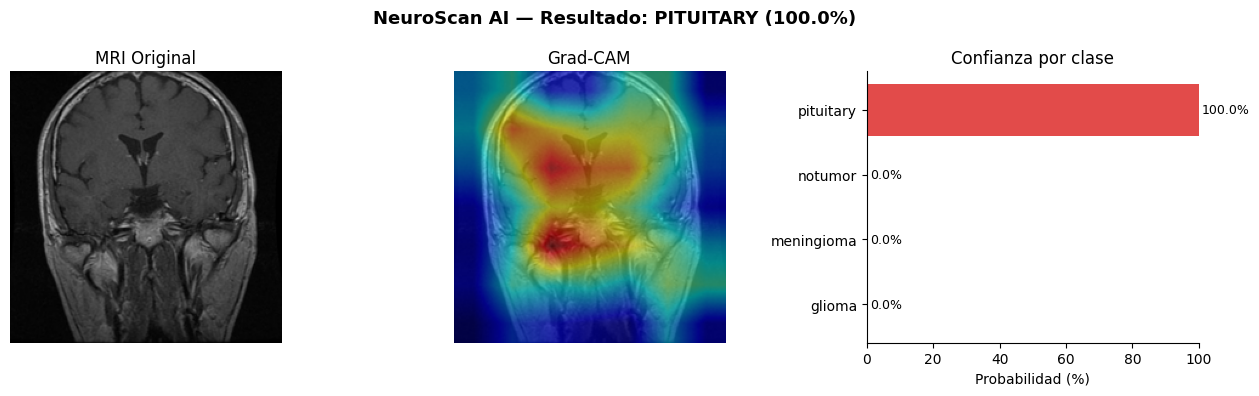


── Resultado ──────────────────────────────
  Clase predicha : pituitary
  Confianza      : 99.97%
  Descripción    : Tumor en la glándula pituitaria. Tratable con cirugía/radioterapia.

  Probabilidades por clase:
    glioma                            0.0%
    meningioma                        0.0%
    notumor                           0.0%
    pituitary    ███████████████████  100.0%

  ¿Correcto? ✅ (real=pituitary, pred=pituitary)


In [ ]:
# Tomar una imagen aleatoria del test set
import random
sample_path, sample_label = random.choice(test_dataset.samples)
label_real = CLASS_NAMES[sample_label]

print(f"Imagen seleccionada: {sample_path}")
print(f"Etiqueta real      : {label_real}\n")

resultado = predict(sample_path, show_gradcam=True)

print("\n── Resultado ──────────────────────────────")
print(f"  Clase predicha : {resultado['clase']}")
print(f"  Confianza      : {resultado['confianza']}%")
print(f"  Descripción    : {resultado['descripcion']}")
print(f"\n  Probabilidades por clase:")
for clase, prob in resultado["probabilidades"].items():
    barra = "█" * int(prob / 5)
    print(f"    {clase:12s} {barra:20s} {prob:.1f}%")
print(f"\n  ¿Correcto? {'✅' if resultado['clase'] == label_real else '❌'} "
      f"(real={label_real}, pred={resultado['clase']})")

# 26. Descargar modelo entrenado

In [ ]:
from google.colab import files

# Guardar modelo completo con metadata
torch.save({
    "model_state_dict": model.state_dict(),
    "class_names":      CLASS_NAMES,
    "img_size":         IMG_SIZE,
    "val_loss":         0.0774,
}, "neuroscan_ai_final.pt")

# Descargar a tu computadora
files.download("neuroscan_ai_final.pt")
files.download("learning_curves.png")
files.download("confusion_matrix.png")
files.download("gradcam.png")

print("✅ Archivos descargados:")
print("   - neuroscan_ai_final.pt  (modelo)")
print("   - learning_curves.png    (curvas de aprendizaje)")
print("   - confusion_matrix.png   (matriz de confusión)")
print("   - gradcam.png            (visualizaciones)")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Archivos descargados:
   - neuroscan_ai_final.pt  (modelo)
   - learning_curves.png    (curvas de aprendizaje)
   - confusion_matrix.png   (matriz de confusión)
   - gradcam.png            (visualizaciones)


In [ ]:
  from google.colab import files
  import os, shutil, zipfile

  os.makedirs("demo_images", exist_ok=True)
  for clase in ["glioma", "meningioma", "notumor", "pituitary"]:
      folder = f"brain_tumor_data/Testing/{clase}"
      imgs = os.listdir(folder)[:3]          # 3 imágenes por clase
      for img in imgs:
          shutil.copy(f"{folder}/{img}", f"demo_images/{clase}_{img}")

  shutil.make_archive("demo_images", "zip", "demo_images")
  files.download("demo_images.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>